**Jason Scott, DATASCI W210, SPRING 2026**

# Modeling Pipeline for FMA + Ads Datasets

## 0: Setup & Load Pre-Z FMA Data to S3 (SKIP THIS CELL)

In [ ]:
# ============================================================
# RECREATE FMA FILE PRE-Z
# ============================================================

# Clone FMA repo for utils
!git clone https://github.com/mdeff/fma.git
import sys
sys.path.append('/content/fma')
from utils import load

import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

local_dir = '/content/drive/MyDrive/Colab Notebooks/MIDS/210/data/fma'

# Load raw files
echonest = load(local_dir + '/echonest.csv')
features = load(local_dir + '/features.csv')
genres = load(local_dir + '/genres.csv')
tracks = load(local_dir + '/tracks.csv')

# Align to common echonest index
common_index = tracks.index.intersection(echonest.index)
echonest_aligned = echonest.loc[common_index]
features_aligned = features.loc[common_index]
tracks_aligned = tracks.loc[common_index]

# Flatten multi-index columns
echonest_flat = echonest_aligned.copy()
echonest_flat.columns = ['_'.join(col).strip() for col in echonest_flat.columns.values]

features_flat = features_aligned.copy()
features_flat.columns = ['_'.join(col).strip() for col in features_flat.columns.values]

tracks_flat = tracks_aligned.copy()
tracks_flat.columns = ['_'.join(col).strip() for col in tracks_flat.columns.values]

# Combine
eda_df = pd.concat([tracks_flat, features_flat, echonest_flat], axis=1)

# Map genres
genre_map = genres['title'].to_dict()
eda_df['track_genres_name'] = eda_df['track_genres'].apply(
    lambda x: genre_map.get(int(x[0])) if isinstance(x, list) and x else None
)
eda_df['track_genres_all_names'] = eda_df['track_genres_all'].apply(
    lambda ids: [genre_map.get(int(i)) for i in ids] if isinstance(ids, list) else []
)

# Quick sanity check on echonest scale — should be 0-1
ECHONEST_FEATURES = [
    'echonest_audio_features_acousticness',
    'echonest_audio_features_danceability',
    'echonest_audio_features_energy',
    'echonest_audio_features_instrumentalness',
    'echonest_audio_features_liveness',
    'echonest_audio_features_speechiness',
    'echonest_audio_features_tempo',
    'echonest_audio_features_valence'
]
print(eda_df[ECHONEST_FEATURES].describe().round(3))

# Save original-scale version
save_path = local_dir + '/fma_pre_z.csv'
eda_df.to_csv(save_path, index=False)
print(f"Saved to {save_path}")

Cloning into 'fma'...
remote: Enumerating objects: 823, done.
remote: Counting objects: 100% (822/822), done.
remote: Compressing objects: 100% (287/287), done.
remote: Total 823 (delta 532), reused 621 (delta 527), pack-reused 1 (from 1)
Receiving objects: 100% (823/823), 4.08 MiB | 17.25 MiB/s, done.
Resolving deltas: 100% (532/532), done.


MessageError: Error: credential propagation was unsuccessful

In [ ]:

# ============================================================
# UPLOAD PRE-Z FILE TO S3
# ============================================================

import boto3
from google.colab import drive
from google.colab import userdata

drive.mount('/content/drive')

# S3 setup
s3 = boto3.client(
    's3',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name='us-west-2'
)

BUCKET = 'mids-capstone-music-ad-matching-2026'

s3.upload_file(
    '/content/drive/MyDrive/Colab Notebooks/MIDS/210/data/fma/fma_pre_z.csv',
    BUCKET,
    'processed-data/fma/fma_pre_z.csv'
)
print("Uploaded to S3")

## --> ======= RUN THIS CELL AND BELOW (CMD + fn + F10) ======= <--

## 1: V1 - Feature Engineering & Euclidean Distance Matching

This section builds the v1 music-to-ad matching pipeline using Echonest audio features from
the FMA dataset and synthetic ad annotations.

### Steps
1. Load FMA track data and ad annotations from S3
2. Engineer popularity features using log1p transform and quartile bucketing
3. Validate Echonest feature scales and normalize tempo to 0-1
4. Convert ad annotations to numeric target vectors using fixed midpoint mappings
5. Build Euclidean distance matching function with indie popularity boost
6. Run matching across all 300 ads and evaluate coverage and diversity
7. Save `v1_matches_with_meta.csv` to S3

### Data Sources
- **FMA track data** (`fma_pre_z.csv`): 13,129 tracks with 8 Echonest audio features in original scale (0-1)
- **Ad annotations** (`ads_df_post_eda.csv`): 300 ads annotated across Energy (1-5), Tempo (Slow/Medium/Fast), and Mood (Positive/Neutral/Serious)

### Evaluation Metrics

| Metric | Target | V1 Result |
|--------|--------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% (300/300) |
| Artist diversity (unique per top-10) | >0.7 | 0.995 |
| Match score range | <0.3 | 0.004–0.099 |
| Human listening score | >3.5/5 | TBD |

&nbsp;


In [ ]:
!pip install boto3 -q
!pip install h5py -q

In [ ]:
# =================================================================
# 1.1) SETUP & DATA LOADING
# =================================================================

import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# S3 setup
print("Connecting to S3...")
s3 = boto3.client(
    's3',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name='us-west-2'
)
print("S3 connection established.")

BUCKET = 'mids-capstone-music-ad-matching-2026'

# Download datasets from S3
print("\nDownloading datasets from S3...")
s3.download_file(BUCKET, 'processed-data/fma/fma_pre_z.csv', 'fma.csv')
print("- fma_pre_z.csv downloaded.")
s3.download_file(BUCKET, 'processed-data/synthetic-annotations/ads_df_post_eda.csv', 'ads.csv')
print("- ads_df_post_eda.csv downloaded.")

# Load data
print("\nLoading data into dataframes...")
df_fma = pd.read_csv('fma.csv')
df_ads = pd.read_csv('ads.csv')
print(f"- FMA: {df_fma.shape}")
print(f"- Ads: {df_ads.shape}")
print("Data loading complete.\n")

Connecting to S3...
S3 connection established.

- fma_pre_z.csv downloaded.
- ads_df_post_eda.csv downloaded.

Loading data into dataframes...
- FMA: (13129, 821)
- Ads: (300, 15)
Data loading complete.



/tmp/ipython-input-2468721144.py:33: DtypeWarning: Columns (42,47,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fma = pd.read_csv('fma.csv')


In [ ]:
# =================================================================
# 1.2) FMA POPULARITY FEATURE ENGINEERING
# =================================================================

print("\nEngineering popularity features...")

# Log transform
df_fma['log_track_listens'] = np.log1p(df_fma['track_listens'])
df_fma['log_track_favorites'] = np.log1p(df_fma['track_favorites'])
print("- Log transform applied to track_listens and track_favorites.")

# Popularity bucket
df_fma['popularity_bucket'] = pd.qcut(
    df_fma['log_track_listens'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)
print("- Popularity buckets created.\n")

print(df_fma[['log_track_listens', 'log_track_favorites', 'popularity_bucket']].describe())
print("\nBucket distribution:")
print(df_fma['popularity_bucket'].value_counts().sort_index())


Engineering popularity features...
- Log transform applied to track_listens and track_favorites.
- Popularity buckets created.

       log_track_listens  log_track_favorites
count       13129.000000         13129.000000
mean            6.619078             1.028984
std             1.301272             0.925899
min             2.564949             0.000000
25%             5.703782             0.000000
50%             6.543912             0.693147
75%             7.447168             1.609438
max            13.205330             7.301822

Bucket distribution:
popularity_bucket
Low         3290
Mid-Low     3282
Mid-High    3280
High        3277
Name: count, dtype: int64


In [ ]:
# =================================================================
# 1.3) FMA FEATURE SCALE VALIDATION + TEMPO NORMALIZATION (0-1)
# =================================================================

print("\nValidating feature scales...")

ECHONEST_FEATURES = [
    'echonest_audio_features_acousticness',
    'echonest_audio_features_danceability',
    'echonest_audio_features_energy',
    'echonest_audio_features_instrumentalness',
    'echonest_audio_features_liveness',
    'echonest_audio_features_speechiness',
    'echonest_audio_features_tempo',
    'echonest_audio_features_valence'
]

POPULARITY_COLS = ['log_track_listens', 'log_track_favorites', 'popularity_bucket']

df_features = df_fma[ECHONEST_FEATURES + POPULARITY_COLS].copy()

print("=== Scale Check (echonest features) ===")
for col in ECHONEST_FEATURES:
    print(f"  {col.replace('echonest_audio_features_', '')}: "
          f"min={df_features[col].min():.3f}, "
          f"max={df_features[col].max():.3f}, "
          f"mean={df_features[col].mean():.3f}")

print("\nNormalizing tempo to 0-1 scale...")
TEMPO_MIN = df_features['echonest_audio_features_tempo'].min()
TEMPO_MAX = df_features['echonest_audio_features_tempo'].max()

df_features['echonest_audio_features_tempo_norm'] = (
    (df_features['echonest_audio_features_tempo'] - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN)
)

print(f"  Tempo normalized — min: {df_features['echonest_audio_features_tempo_norm'].min():.3f}, "
      f"max: {df_features['echonest_audio_features_tempo_norm'].max():.3f}")


Validating feature scales...
=== Scale Check (echonest features) ===
  acousticness: min=0.000, max=0.996, mean=0.525
  danceability: min=0.051, max=0.969, mean=0.487
  energy: min=0.000, max=1.000, mean=0.538
  instrumentalness: min=0.000, max=0.998, mean=0.641
  liveness: min=0.025, max=0.980, mean=0.188
  speechiness: min=0.022, max=0.966, mean=0.099
  tempo: min=12.753, max=251.072, mean=123.080
  valence: min=0.000, max=1.000, mean=0.440

Normalizing tempo to 0-1 scale...
  Tempo normalized — min: 0.000, max: 1.000


In [ ]:
# =================================================================
# 1.4) AD FEATURE VECTOR CONSTRUCTION
# =================================================================

print("\nConstructing ad feature vectors...")

ENERGY_MAP = {1: 0.1, 2: 0.3, 3: 0.5, 4: 0.7, 5: 0.9}

TEMPO_MAP = {
    'Slow':   (70 - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN),
    'Medium': (115 - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN),
    'Fast':   (190 - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN)
}

MOOD_MAP = {'Positive': 0.75, 'Neutral': 0.5, 'Serious': 0.25}

df_ads['target_energy'] = df_ads['energy_1_5'].map(ENERGY_MAP)
df_ads['target_tempo']  = df_ads['tempo'].map(TEMPO_MAP)
df_ads['target_valence'] = df_ads['mood'].map(MOOD_MAP)

print("Vector construction complete.")

print("\n=== Ad Feature Vector Sample ===")
print(df_ads[['ad_id', 'energy_1_5', 'tempo', 'mood',
              'target_energy', 'target_tempo', 'target_valence']].head(5))

print("\nNull check:")
print(df_ads[['target_energy', 'target_tempo', 'target_valence']].isnull().sum())



Constructing ad feature vectors...
Vector construction complete.

=== Ad Feature Vector Sample ===
    ad_id  energy_1_5   tempo      mood  target_energy  target_tempo  \
0  JS_001           4  Medium  Positive            0.7      0.429034   
1  JS_002           5    Fast  Positive            0.9      0.743738   
2  JS_003           2    Slow  Positive            0.3      0.240212   
3  JS_004           3  Medium  Positive            0.5      0.429034   
4  JS_005           5    Fast  Positive            0.9      0.743738   

   target_valence  
0            0.75  
1            0.75  
2            0.75  
3            0.75  
4            0.75  

Null check:
target_energy     0
target_tempo      0
target_valence    0
dtype: int64


In [ ]:
# =================================================================
# 1.5) MATCHING FUNCTION (V1 - Euclidean Distance)
# =================================================================

print("\nDefining V1 matching function...")

POPULARITY_PENALTY = 0.20

def match_tracks(ad_row, df_tracks, top_n=10):
    scores = np.zeros(len(df_tracks))

    scores += (df_tracks['echonest_audio_features_energy'].values - ad_row['target_energy']) ** 2
    scores += (df_tracks['echonest_audio_features_tempo_norm'].values - ad_row['target_tempo']) ** 2
    scores += (df_tracks['echonest_audio_features_valence'].values - ad_row['target_valence']) ** 2

    scores = np.sqrt(scores)

    high_mask = df_tracks['popularity_bucket'].values == 'High'
    scores[high_mask] *= (1 + POPULARITY_PENALTY)

    results = df_tracks.copy()
    results['match_score'] = scores
    return results.nsmallest(top_n, 'match_score')[
        ['match_score', 'popularity_bucket',
         'echonest_audio_features_energy',
         'echonest_audio_features_tempo_norm',
         'echonest_audio_features_valence']
    ].reset_index()

print("Function definition complete.")

# Test on first ad
test_ad = df_ads.iloc[0]
print(f"\nTest run — Ad: {test_ad['ad_id']} | Energy={test_ad['energy_1_5']} | "
      f"Tempo={test_ad['tempo']} | Mood={test_ad['mood']}")
top_matches = match_tracks(test_ad, df_features)
print(f"\nTop 10 Matches:")
print(top_matches)


Defining V1 matching function...
Function definition complete.

Test run — Ad: JS_001 | Energy=4 | Tempo=Medium | Mood=Positive

Top 10 Matches:
   index  match_score popularity_bucket  echonest_audio_features_energy  \
0   7021     0.013291               Low                        0.701927   
1   8487     0.022406               Low                        0.696592   
2  12760     0.023228          Mid-High                        0.700277   
3   3402     0.027047              High                        0.691026   
4  10643     0.031077           Mid-Low                        0.693947   
5  12527     0.032262           Mid-Low                        0.670842   
6   4007     0.035103           Mid-Low                        0.681433   
7   4448     0.035384               Low                        0.732042   
8  12281     0.041093          Mid-High                        0.700450   
9  12640     0.044796          Mid-High                        0.698086   

   echonest_audio_features_t

In [ ]:
# =================================================================
# 1.6) RUN MATCHING ACROSS ALL 300 ADS + COVERAGE/DIVERSITY CHECK
# =================================================================

print("\nRunning v1 matching across all 300 ads...")

results = {}
for _, ad_row in df_ads.iterrows():
    results[ad_row['ad_id']] = match_tracks(ad_row, df_features, top_n=10)
print("Matching complete.")

print("\nJoining track and ad metadata...")
v1_matches = pd.concat([v.assign(ad_id=k) for k, v in results.items()])

META_COLS = [
    'artist_name',
    'track_title',
    'track_genres_name',
    'track_listens',
    'log_track_listens',
    'popularity_bucket'
]

v1_matches_with_meta = v1_matches.merge(
    df_fma[META_COLS],
    left_on='index',
    right_index=True,
    suffixes=('', '_meta')
).merge(
    df_ads[['ad_id', 'industry', 'brand', 'product', 'energy_1_5', 'tempo', 'mood', 'url']],
    on='ad_id'
)
print(f"Metadata join complete. Final shape: {v1_matches_with_meta.shape}")

print("\n=== Coverage Check ===")
print(f"- Total ads matched: {len(results)}")
print(f"- Ads with 10 matches: {sum(len(v) == 10 for v in results.values())}")
print(f"- Total match records: {len(v1_matches_with_meta)}")
print(f"- Score range: {v1_matches_with_meta['match_score'].min():.3f} - {v1_matches_with_meta['match_score'].max():.3f}")
print(f"- Mean score: {v1_matches_with_meta['match_score'].mean():.3f}")
print('')
print(v1_matches_with_meta['popularity_bucket'].value_counts())

print("\n=== Diversity Check ===")
diversity = v1_matches_with_meta.groupby('ad_id')['artist_name'].nunique()
print(f"- Mean unique artists per ad: {diversity.mean():.2f}")
print(f"- Ads with all unique artists (10/10): {(diversity == 10).sum()}")


Running v1 matching across all 300 ads...
Matching complete.

Joining track and ad metadata...
Metadata join complete. Final shape: (3000, 20)

=== Coverage Check ===
- Total ads matched: 300
- Ads with 10 matches: 300
- Total match records: 3000
- Score range: 0.004 - 0.099
- Mean score: 0.040

popularity_bucket
Low         903
Mid-Low     808
Mid-High    757
High        532
Name: count, dtype: int64

=== Diversity Check ===
- Mean unique artists per ad: 9.95
- Ads with all unique artists (10/10): 286


In [ ]:
# =================================================================
# 1.7) SAVE RESULTS TO S3
# =================================================================

print("\nSaving v1 results to S3...")
v1_matches_with_meta.to_csv('v1_matches_with_meta.csv', index=False)
s3.upload_file('v1_matches_with_meta.csv', BUCKET, 'outputs/v1-matching/v1_matches_with_meta.csv')
print("Upload complete: outputs/v1-matching/v1_matches_with_meta.csv")


Saving v1 results to S3...
Upload complete: outputs/v1-matching/v1_matches_with_meta.csv


## 2: V2 - Librosa + PCA Matching

This section extends v1 by incorporating 511 librosa audio features (MFCCs, chroma, spectral,
ZCR, tonnetz) to capture timbral and textural characteristics not captured by Echonest features
alone. PCA is used to reduce dimensionality before distance calculation.

### Steps
1. Extract and select librosa features from `df_fma` (MFCCs, chroma, spectral, ZCR, tonnetz)
2. Dimensionality reduction with PCA (511 → 144 components, 90.1% variance retained)
3. Build enriched distance function combining 3 primary Echonest features + 144 PCA components
4. Compare v2 vs v1 results on same 300 ads
5. Save `v2_matches_with_meta.csv` to S3

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result |
|--------|--------|-----------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% | 100% |
| Artist diversity (unique per top-10) | >0.7 | 0.995 | 0.995 |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 |
| Human listening score | >3.5/5 | TBD | TBD |

&nbsp;

In [ ]:
# =================================================================
# 2.1) EXTRACT LIBROSA FEATURES
# =================================================================

print("Extracting librosa features...")

librosa_cols = [col for col in df_fma.columns if col.startswith('mfcc')
                or col.startswith('chroma')
                or col.startswith('spectral')
                or col.startswith('tonnetz')
                or col.startswith('zcr')]

df_librosa = df_fma[librosa_cols].copy()

print(f"- Librosa feature matrix shape: {df_librosa.shape}")
print(f"- Null check: {df_librosa.isnull().sum().sum()} total nulls")
print(f"\nFeature groups:")
for prefix in ['mfcc', 'chroma', 'spectral', 'tonnetz', 'zcr']:
    count = len([c for c in librosa_cols if c.startswith(prefix)])
    print(f"- {prefix}: {count} columns")

Extracting librosa features...
- Librosa feature matrix shape: (13129, 511)
- Null check: 0 total nulls

Feature groups:
- mfcc: 140 columns
- chroma: 252 columns
- spectral: 70 columns
- tonnetz: 42 columns
- zcr: 7 columns


Scaling librosa features...
Scaling complete.

Fitting PCA...


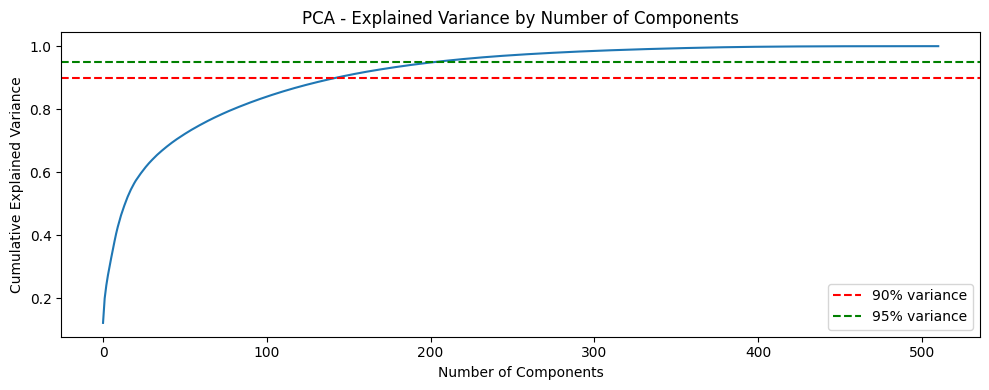


- Components for 90% variance: 144
- Components for 95% variance: 205

Applying PCA transform with 144 components (90% variance)...
- PCA feature matrix shape: (13129, 144)
- Explained variance retained: 0.901


In [ ]:
# =================================================================
# 2.2) DIMENSIONALITY REDUCTION WITH PCA
# =================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Scaling librosa features...")
scaler = StandardScaler()
df_librosa_scaled = scaler.fit_transform(df_librosa)
print("Scaling complete.")

print("\nFitting PCA...")
pca_full = PCA()
pca_full.fit(df_librosa_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(10, 4))
plt.plot(cumvar)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance by Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"\n- Components for 90% variance: {n_90}")
print(f"- Components for 95% variance: {n_95}")

print(f"\nApplying PCA transform with {n_90} components (90% variance)...")
N_COMPONENTS = n_90

pca = PCA(n_components=N_COMPONENTS)
df_librosa_pca = pca.fit_transform(df_librosa_scaled)

df_librosa_pca = pd.DataFrame(
    df_librosa_pca,
    index=df_fma.index,
    columns=[f'pca_{i+1:03d}' for i in range(N_COMPONENTS)]
)

print(f"- PCA feature matrix shape: {df_librosa_pca.shape}")
print(f"- Explained variance retained: {pca.explained_variance_ratio_.sum():.3f}")

In [ ]:
# =================================================================
# 2.3) BUILD V2 MATCHING FUNCTION (Echonest + PCA)
# =================================================================

print("\nDefining V2 matching function...")

PCA_WEIGHT = 0.3

def match_tracks_v2(ad_row, df_tracks, df_pca, top_n=10):
    scores = np.zeros(len(df_tracks))

    scores += (df_tracks['echonest_audio_features_energy'].values - ad_row['target_energy']) ** 2
    scores += (df_tracks['echonest_audio_features_tempo_norm'].values - ad_row['target_tempo']) ** 2
    scores += (df_tracks['echonest_audio_features_valence'].values - ad_row['target_valence']) ** 2

    pca_centroid = df_pca.mean().values
    pca_distances = np.sum((df_pca.values - pca_centroid) ** 2, axis=1)
    pca_distances = pca_distances / pca_distances.max()
    scores += PCA_WEIGHT * pca_distances

    scores = np.sqrt(scores)

    high_mask = df_tracks['popularity_bucket'].values == 'High'
    scores[high_mask] *= (1 + POPULARITY_PENALTY)

    results = df_tracks.copy()
    results['match_score'] = scores
    return results.nsmallest(top_n, 'match_score')[
        ['match_score', 'popularity_bucket',
         'echonest_audio_features_energy',
         'echonest_audio_features_tempo_norm',
         'echonest_audio_features_valence']
    ].reset_index()

print("Function definition complete.")

# Test on first ad
test_ad = df_ads.iloc[0]
print(f"\nTest run — Ad: {test_ad['ad_id']} | Energy={test_ad['energy_1_5']} | "
      f"Tempo={test_ad['tempo']} | Mood={test_ad['mood']}")
top_matches_v2 = match_tracks_v2(test_ad, df_features, df_librosa_pca)
print(f"\nTop 10 Matches:")
print(top_matches_v2)



Defining V2 matching function...
Function definition complete.

Test run — Ad: JS_001 | Energy=4 | Tempo=Medium | Mood=Positive

Top 10 Matches:
   index  match_score popularity_bucket  echonest_audio_features_energy  \
0   8487     0.029538               Low                        0.696592   
1  12760     0.031288          Mid-High                        0.700277   
2   7021     0.031683               Low                        0.701927   
3  12527     0.039049           Mid-Low                        0.670842   
4  10643     0.040488           Mid-Low                        0.693947   
5   4448     0.040960               Low                        0.732042   
6   4007     0.041956           Mid-Low                        0.681433   
7   3402     0.045899              High                        0.691026   
8  12281     0.046579          Mid-High                        0.700450   
9  12640     0.051723          Mid-High                        0.698086   

   echonest_audio_features_t

In [ ]:
# =================================================================
# 2.4) RUN V2 MATCHING ACROSS ALL 300 ADS + COVERAGE/DIVERSITY CHECK
# =================================================================

# Genre-to-industry mapping
GENRE_INDUSTRY_MAP = {
    'Electronic':          ['Tech', 'Entertainment'],
    'Chiptune':            ['Tech', 'Entertainment'],
    'Sound Art':           ['Tech', 'Entertainment'],
    'Rock':                ['Automotive', 'Entertainment'],
    'Punk':                ['Entertainment', 'Retail'],
    'Post-Punk':           ['Entertainment', 'Retail'],
    'Post-Rock':           ['Automotive', 'Entertainment'],
    'Metal':               ['Automotive', 'Entertainment'],
    'Psych-Rock':          ['Entertainment', 'Retail'],
    'Indie-Rock':          ['Retail', 'Entertainment', 'F&B'],
    'Pop':                 ['Retail', 'F&B', 'Healthcare', 'Entertainment'],
    'Hip-Hop':             ['Retail', 'Entertainment', 'Automotive'],
    'Trip-Hop':            ['Retail', 'Finance', 'Healthcare'],
    'Folk':                ['F&B', 'Healthcare', 'Retail'],
    'Psych-Folk':          ['F&B', 'Entertainment', 'Retail'],
    'Old-Time / Historic': ['F&B', 'Finance', 'Retail'],
    'Jazz':                ['Finance', 'F&B', 'Healthcare'],
    'Blues':               ['F&B', 'Entertainment'],
    'Classical':           ['Finance', 'Healthcare', 'F&B'],
    'Soundtrack':          ['Automotive', 'Entertainment', 'Finance'],
    'International':       ['F&B', 'Entertainment', 'Retail'],
    'Kid-Friendly':        ['F&B', 'Healthcare', 'Retail'],
    'Compilation':         ['Retail', 'Entertainment']
}

# Build reverse lookup: industry -> list of valid genres
def get_valid_genres(industry):
    return [genre for genre, industries in GENRE_INDUSTRY_MAP.items()
            if industry in industries]

print("\nRunning V2 matching across all 300 ads (with genre filter)...")

results_v2 = {}
skipped = 0
for _, ad_row in df_ads.iterrows():
    industry = ad_row['industry']
    valid_genres = get_valid_genres(industry)

    # Filter tracks by valid genres — fall back to full pool if no matches
    if valid_genres and industry != 'Other':
        df_filtered = df_features[
            df_fma['track_genres_name'].isin(valid_genres)
        ].copy()
    else:
        df_filtered = df_features.copy()

    # Fall back to full pool if filtered set is too small
    if len(df_filtered) < 10:
        df_filtered = df_features.copy()
        skipped += 1

    # Filter df_librosa_pca to match
    df_pca_filtered = df_librosa_pca.loc[df_filtered.index]

    results_v2[ad_row['ad_id']] = match_tracks_v2(ad_row, df_filtered, df_pca_filtered, top_n=5)

print(f"Matching complete. ({skipped} ads fell back to full track pool)")

print("\nJoining track and ad metadata...")
v2_matches = pd.concat([v.assign(ad_id=k) for k, v in results_v2.items()])

v2_matches_with_meta = v2_matches.merge(
    df_fma[META_COLS],
    left_on='index',
    right_index=True,
    suffixes=('', '_meta')
).merge(
    df_ads[['ad_id', 'industry', 'brand', 'product', 'energy_1_5', 'tempo', 'mood', 'url']],
    on='ad_id'
)
print(f"Metadata join complete. Final shape: {v2_matches_with_meta.shape}")

print("\n=== Coverage Check ===")
print(f"- Total ads matched: {len(results_v2)}")
print(f"- Ads with 5 matches: {sum(len(v) == 5 for v in results_v2.values())}")
print(f"- Total match records: {len(v2_matches_with_meta)}")
print(f"- Score range: {v2_matches_with_meta['match_score'].min():.3f} - {v2_matches_with_meta['match_score'].max():.3f}")
print(f"- Mean score: {v2_matches_with_meta['match_score'].mean():.3f}")
print("\nPopularity distribution in matches:")
print(v2_matches_with_meta['popularity_bucket'].value_counts())

print("\n=== Diversity Check ===")
diversity_v2 = v2_matches_with_meta.groupby('ad_id')['artist_name'].nunique()
print(f"- Mean unique artists per ad: {diversity_v2.mean():.2f}")
print(f"- Ads with all unique artists (5/5): {(diversity_v2 == 5).sum()}")

print("\nGenre distribution in matches:")
print(v2_matches_with_meta['track_genres_name'].value_counts())


Running V2 matching across all 300 ads (with genre filter)...
Matching complete. (0 ads fell back to full track pool)

Joining track and ad metadata...
Metadata join complete. Final shape: (1500, 20)

=== Coverage Check ===
- Total ads matched: 300
- Ads with 5 matches: 300
- Total match records: 1500
- Score range: 0.024 - 0.189
- Mean score: 0.072

Popularity distribution in matches:
popularity_bucket
Low         467
Mid-Low     461
Mid-High    405
High        167
Name: count, dtype: int64

=== Diversity Check ===
- Mean unique artists per ad: 4.91
- Ads with all unique artists (5/5): 276

Genre distribution in matches:
track_genres_name
Pop                    317
Electronic             304
Jazz                   173
Rock                   164
Folk                   162
Hip-Hop                108
Indie-Rock              54
International           46
Post-Punk               40
Psych-Folk              27
Punk                    27
Trip-Hop                16
Classical               13


In [ ]:
# =================================================================
# 2.5) SAVE V2 RESULTS TO S3
# =================================================================

print("\nSaving V2 results to S3...")
v2_matches_with_meta.to_csv('v2_matches_with_meta.csv', index=False)
s3.upload_file('v2_matches_with_meta.csv', BUCKET, 'outputs/v2-matching/v2_matches_with_meta.csv')
print("Upload complete: outputs/v2-matching/v2_matches_with_meta.csv")


Saving V2 results to S3...
Upload complete: outputs/v2-matching/v2_matches_with_meta.csv


In [ ]:
# =================================================================
# 2.6) BUILD HUMAN EVALUATION DATASET
# =================================================================

import random

random.seed(42)

# Add match_rank 1-5 (already top 5 from 2.4)
v2_eval = v2_matches_with_meta.copy()

v2_eval['match_rank'] = (
    v2_eval.groupby('ad_id')['match_score']
    .rank(method='first')
    .astype(int)
)

# Randomly assign evaluator to each ad
evaluators = ['Christine', 'Jashan', 'Jason', 'Tommy']
ad_ids = v2_eval['ad_id'].unique()
ad_evaluator_map = {ad: evaluators[i % 4] for i, ad in enumerate(random.sample(list(ad_ids), len(ad_ids)))}
v2_eval['evaluator'] = v2_eval['ad_id'].map(ad_evaluator_map)

# Add placeholder columns for human evaluation
v2_eval['self_rank_overall'] = ''
v2_eval['self_rank_energy'] = ''
v2_eval['self_rank_tempo'] = ''
v2_eval['self_rank_mood'] = ''
v2_eval['self_fit_overall'] = ''

# Reorder columns for readability
front_cols = [
    'ad_id',
    'evaluator',
    'industry',
    'brand',
    'product',
    'energy_1_5',
    'tempo',
    'mood',
    'url',
    'match_rank',
    'self_rank_overall',
    'self_rank_energy',
    'self_rank_tempo',
    'self_rank_mood',
    'self_fit_overall',
    'artist_name',
    'track_title',
    'track_genres_name',
    'match_score',
    'popularity_bucket',
    'track_listens',
]

remaining_cols = [c for c in v2_eval.columns if c not in front_cols
                  and c not in ['index', 'popularity_bucket_meta']]

v2_eval = v2_eval[front_cols + remaining_cols]

print(f"Evaluation dataset shape: {v2_eval.shape}")
print(f"\nEvaluator distribution (ads):")
print(v2_eval.drop_duplicates('ad_id')['evaluator'].value_counts())
print(f"\nSample:")
print(v2_eval[['ad_id', 'match_rank', 'evaluator', 'artist_name', 'track_title', 'match_score']].head(10))



Evaluation dataset shape: (1500, 25)

Evaluator distribution (ads):
evaluator
Christine    75
Jason        75
Tommy        75
Jashan       75
Name: count, dtype: int64

Sample:
    ad_id  match_rank  evaluator           artist_name  \
0  JS_001           1  Christine  Brownstone Megaphone   
1  JS_001           2  Christine                  Djet   
2  JS_001           3  Christine          Aleksi Virta   
3  JS_001           4  Christine             The Model   
4  JS_001           5  Christine              Beta Dog   
5  JS_002           1      Jason                  Herv   
6  JS_002           2      Jason                  Inom   
7  JS_002           3      Jason                Eaters   
8  JS_002           4      Jason                Eaters   
9  JS_002           5      Jason             Nullsleep   

                            track_title  match_score  
0                         Cherry Picker     0.031264  
1                               Dispute     0.040547  
2                  

In [ ]:
# =================================================================
# 2.7) SAVE EVALUATION TEMPLATE S3
# =================================================================

print("\nSaving V2 evaluation template to S3...")
v2_eval.to_csv('v2_human_eval.csv', index=False)
s3.upload_file('v2_human_eval.csv', BUCKET, 'outputs/v2-matching/v2_human_eval.csv')
print("Upload complete: outputs/v2-matching/v2_human_eval.csv")


Saving V2 evaluation template to S3...
Upload complete: outputs/v2-matching/v2_human_eval.csv


## 3: V3 - K-Means Clustering

This section explores an unsupervised clustering approach using K-means on the librosa PCA
feature space to pre-group tracks by audio profile, then matches ads to the nearest cluster
centroid before ranking within it.

### Steps
1. Apply K-means clustering to PCA-reduced librosa features
2. Determine optimal k (elbow method + silhouette score)
3. Assign each track to a cluster
4. Match each ad to nearest cluster centroid
5. Rank tracks within matched cluster by Euclidean distance
6. Compare v3 vs v1/v2 results on same 300 ads
7. Save `v3_matches_with_meta.csv` to S3

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result | V3 Result |
|--------|--------|-----------|-----------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% | 100% | TBD |
| Artist diversity (unique per top-10) | >0.7 | 0.995 | 0.995 | TBD |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 | TBD |
| Human listening score | >3.5/5 | TBD | TBD | TBD |

&nbsp;

## 4: V4 - Neural Clustering (Stretch Goal)

This section explores deep neural clustering methods to learn a richer latent representation
of audio features. Candidate approaches include autoencoder-based clustering, Deep Embedded
Clustering (DEC), or a Variational Autoencoder (VAE).

### Steps
1. Select neural clustering architecture (autoencoder / DEC / VAE)
2. Train model on FMA librosa + PCA feature space
3. Extract learned latent embeddings
4. Cluster in latent space and assign tracks
5. Match ads to nearest cluster, rank within cluster
6. Compare v4 vs all prior versions on same 300 ads
7. Save `v4_matches_with_meta.csv` to S3

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result | V3 Result | V4 Result |
|--------|--------|-----------|-----------|-----------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% | 100% | TBD | TBD |
| Artist diversity (unique per top-10) | >0.7 | 0.995 | 0.995 | TBD | TBD |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 | TBD | TBD |
| Human listening score | >3.5/5 | TBD | TBD | TBD | TBD |

&nbsp;